Here we will start with adding the feature MMSE and CDRSB so that some cognitive scores are also there

In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Cell 2: Load Data (Biomarkers + Demographics + Cognitive Scores)
# Replace 'adnimerge.csv' with your actual file path
df = pd.read_csv('adnimerge.csv')

target_col = 'DX'

# We now add MMSE and CDRSB to our base feature list
base_features = ['AGE', 'PTGENDER', 'APOE4', 'ABETA', 'TAU', 'PTAU', 'MMSE', 'CDRSB']

df_model4 = df[['RID', 'VISCODE', target_col] + base_features].copy()

print(f"Initial shape: {df_model4.shape}")

Initial shape: (16421, 11)


In [3]:
# Cell 3: Data Cleaning & Feature Engineering

# 1. Drop rows missing the target diagnosis
df_model4 = df_model4.dropna(subset=[target_col])

# 2. Convert CSF markers to numeric (forces text values to NaN)
for col in ['ABETA', 'TAU', 'PTAU']:
    df_model4[col] = pd.to_numeric(df_model4[col], errors='coerce')

# 3. Drop rows that are missing ANY of the core CSF data
df_model4 = df_model4.dropna(subset=['ABETA', 'TAU', 'PTAU'], how='any')

# 4. ENCODE CATEGORICALS: Convert 'PTGENDER' to numeric
df_model4['PTGENDER'] = df_model4['PTGENDER'].map({'Male': 0, 'Female': 1})

# 5. FEATURE ENGINEERING: Create the protein ratios
df_model4['TAU_ABETA_Ratio'] = df_model4['TAU'] / df_model4['ABETA']
df_model4['PTAU_ABETA_Ratio'] = df_model4['PTAU'] / df_model4['ABETA']

# Define our final feature list including the clinical scores
final_features4 = [
    'AGE', 'PTGENDER', 'APOE4', 
    'ABETA', 'TAU', 'PTAU', 
    'TAU_ABETA_Ratio', 'PTAU_ABETA_Ratio',
    'MMSE', 'CDRSB'   # <--- The powerful new additions
]


# Drop any rows missing the new cognitive scores or demographics
df_model4 = df_model4.dropna(subset=final_features4)

print("Class distribution for target (DX) AFTER clinical feature addition:")
print(df_model4[target_col].value_counts())

# Define X4 and y4
X4 = df_model4[final_features4]
y4 = df_model4[target_col]

Class distribution for target (DX) AFTER clinical feature addition:
DX
MCI         911
CN          576
Dementia    509
Name: count, dtype: int64


In [4]:
# Cell 4: Splitting and Scaling
# Split the data
X_train4, X_test4, y_train4, y_test4 = train_test_split(X4, y4, test_size=0.20, random_state=42, stratify=y4)

# Scale the features
scaler4 = StandardScaler()
X_train_scaled4 = scaler4.fit_transform(X_train4)
X_test_scaled4 = scaler4.transform(X_test4)

print(f"Training features shape: {X_train_scaled4.shape}")

Training features shape: (1596, 10)


In [5]:
# Cell 5: Initialize and Train Model 4
rf_classifier4 = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model
rf_classifier4.fit(X_train_scaled4, y_train4)

print("Model 4 training complete.")

Model 4 training complete.


Accuracy Score: 0.8575

Classification Report:
               precision    recall  f1-score   support

          CN       0.95      0.89      0.92       115
    Dementia       0.80      0.82      0.81       102
         MCI       0.84      0.86      0.85       183

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400



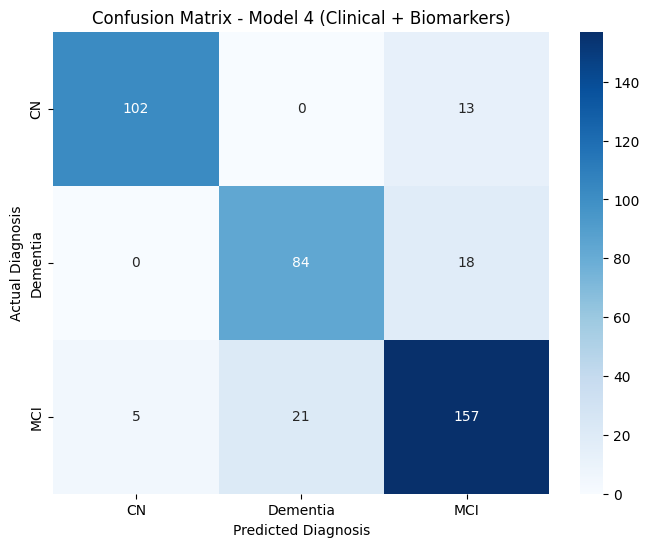

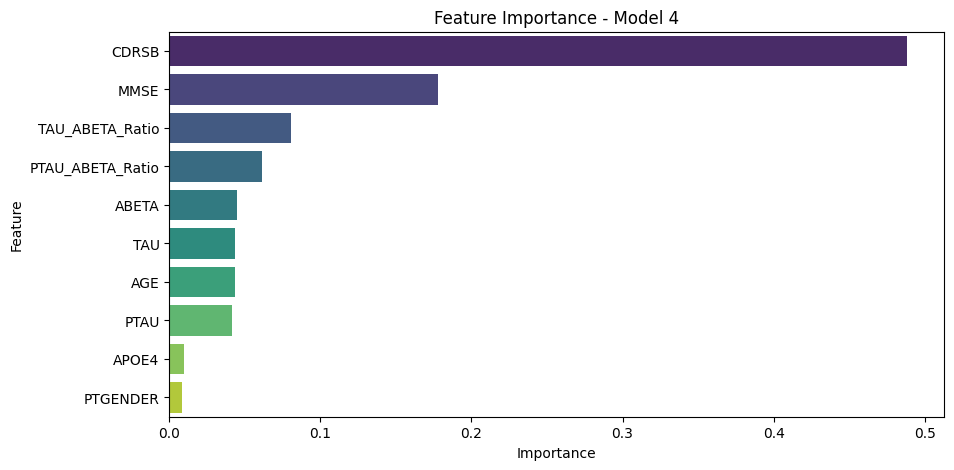

In [6]:
# Cell 6: Predictions and Evaluation
# Make predictions
y_pred4 = rf_classifier4.predict(X_test_scaled4)

# Print metrics
print("Accuracy Score:", accuracy_score(y_test4, y_pred4))
print("\nClassification Report:\n", classification_report(y_test4, y_pred4))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm4 = confusion_matrix(y_test4, y_pred4, labels=rf_classifier4.classes_)
sns.heatmap(cm4, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_classifier4.classes_, 
            yticklabels=rf_classifier4.classes_)
plt.title('Confusion Matrix - Model 4 (Clinical + Biomarkers)')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.show()

# Plot Feature Importance
feature_importances4 = rf_classifier4.feature_importances_
importance_df4 = pd.DataFrame({
    'Feature': final_features4,
    'Importance': feature_importances4
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df4, palette='viridis')
plt.title('Feature Importance - Model 4')
plt.show()